##**SHETH L.U.J. & SIR M.V. COLLEGE**

####Vedant Patil | T101

### **Aim:** K-Means Clustering

* Apply the K-Means algorithm to group similar data points into clusters.
* Determine the optimal number of clusters using elbow method or silhouette analysis.
* Visualize the clustering results and analyze the cluster characteristics.

### **1. Import Required Libraries**



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme()



### **2. Load Dataset**


In [2]:
# Load the pokemon dataset
df = pd.read_csv('pokemon.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (801, 41)


,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0




### **3. Dataset Overview**



In [3]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    object 
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    float64
 15  against_psychic    801 non-null    float64
 16  against_rock       801 non

In [4]:
# Check for null values
df.isna().sum()

,0
abilities,0
against_bug,0
against_dark,0
against_dragon,0
against_electric,0
against_fairy,0
against_fight,0
against_fire,0
against_flying,0
against_ghost,0




### **4. Feature Selection for Clustering**

K-Means works on **numerical data**.

From the Pokemon dataset, we select:

* `attack`
* `defense`

These features represent the combat capability of each Pokemon (Offense vs. Resilience).



In [5]:
# Select features and drop missing values if any
data = df[['attack', 'defense']].dropna()
print("Records used for clustering:", data.shape[0])
data.head()

Records used for clustering: 801


,attack,defense
0,49,49
1,62,63
2,100,123
3,52,43
4,64,58




### **5. Feature Scaling**

K-Means is distance-based, so scaling is important.
We standardize the features so that Attack and Defense contribute equally.


In [6]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_data[:5]

array([[-0.89790944, -0.78077335],
       [-0.49341318, -0.32548801],
       [ 0.6889605 ,  1.62573488],
       [-0.80456415, -0.97589564],
       [-0.43118299, -0.48808992]])



### **6. Elbow Method to Find Optimal Number of Clusters**

The elbow method helps us choose the best value of **K** by plotting:

* Number of clusters (K)
* Within-cluster sum of squares (WCSS)



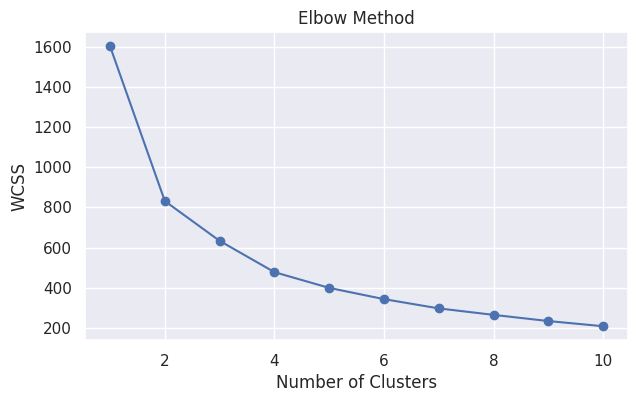

In [7]:
wcss = []

# Loop to try different numbers of clusters from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(7,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()



### **7. Apply K-Means Clustering**

Based on the elbow method (typically where the curve bends), we choose an appropriate number of clusters.
For this Pokemon data, we will choose **K = 4**.


In [8]:
# Apply KMeans with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to the original data
data['Cluster'] = clusters
data.head()

,attack,defense,Cluster
0,49,49,0
1,62,63,2
2,100,123,3
3,52,43,0
4,64,58,0




### **8. Visualizing Clusters**

We visualize clusters using a scatter plot of `attack` vs `defense`.



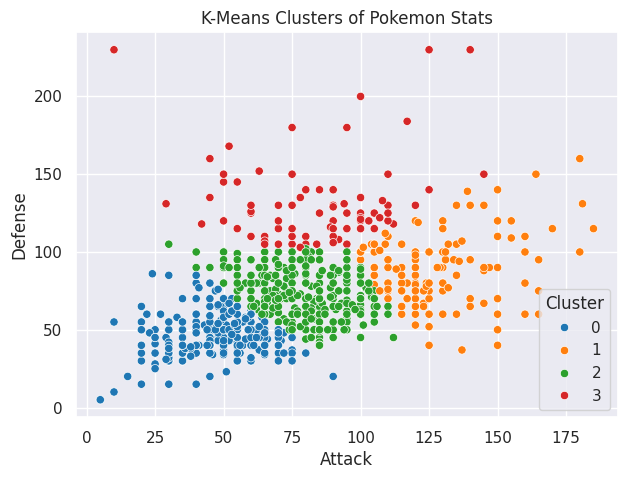

In [9]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=data['attack'],
    y=data['defense'],
    hue=data['Cluster'],
    palette='tab10'
)
plt.title('K-Means Clusters of Pokemon Stats')
plt.xlabel('Attack')
plt.ylabel('Defense')
plt.legend(title='Cluster')
plt.show()



### **9. Cluster Centers**

We inverse transform the centers to see the actual values (not scaled) for interpretation.



In [10]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=['attack', 'defense'])
centers_df

,attack,defense
0,47.807407,46.496296
1,128.042857,90.535714
2,79.537217,72.728155
3,84.792683,131.439024




### **10. Interpretation of Clusters**

Each cluster represents a specific Pokemon archetype:

* **Cluster 0 (Example):** High Defense, Moderate Attack (Defensive Tanks)
* **Cluster 1 (Example):** Low Attack, Low Defense (Base/Early Stage Pokemon)
* **Cluster 2 (Example):** High Attack, High Defense (Elite Physical Fighters)
* **Cluster 3 (Example):** High Attack, Low/Moderate Defense (Glass Cannons)

### **11. Conclusion**

In this practical, we successfully applied **K-Means Clustering** on the Pokemon Dataset.

We:

* Selected relevant combat indicators.
* Scaled the data using Standard Scaler.
* Used the elbow method to determine the optimal clusters.
* Visualized different Pokemon types (Tanks vs. Glass Cannons) using clustering.



# Example 2:

### K-Means Image Color Quantization (Custom Image)

**Dataset:** Custom image file (e.g., Jaipur.jpg)



## Import Required Libraries



In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import MiniBatchKMeans



## Load Custom Image



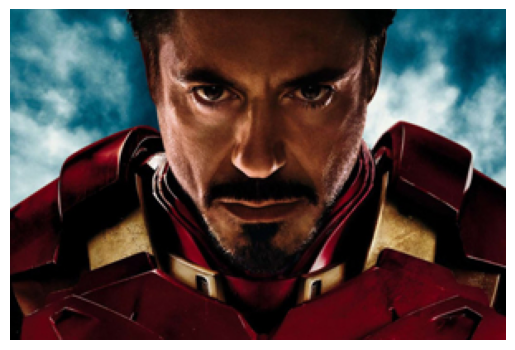

In [12]:
import cv2
import matplotlib.pyplot as plt

# Ensure you have an image file named "download.png" in your directory
img = cv2.imread("download.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()
download = np.array(img)

In [13]:
download.shape

(200, 300, 3)



## Prepare Pixel Data



In [14]:
data_img = download.reshape(-1, 3)
data_img = data_img / 255.0
data_img.shape

(60000, 3)



## Visualize Color Space



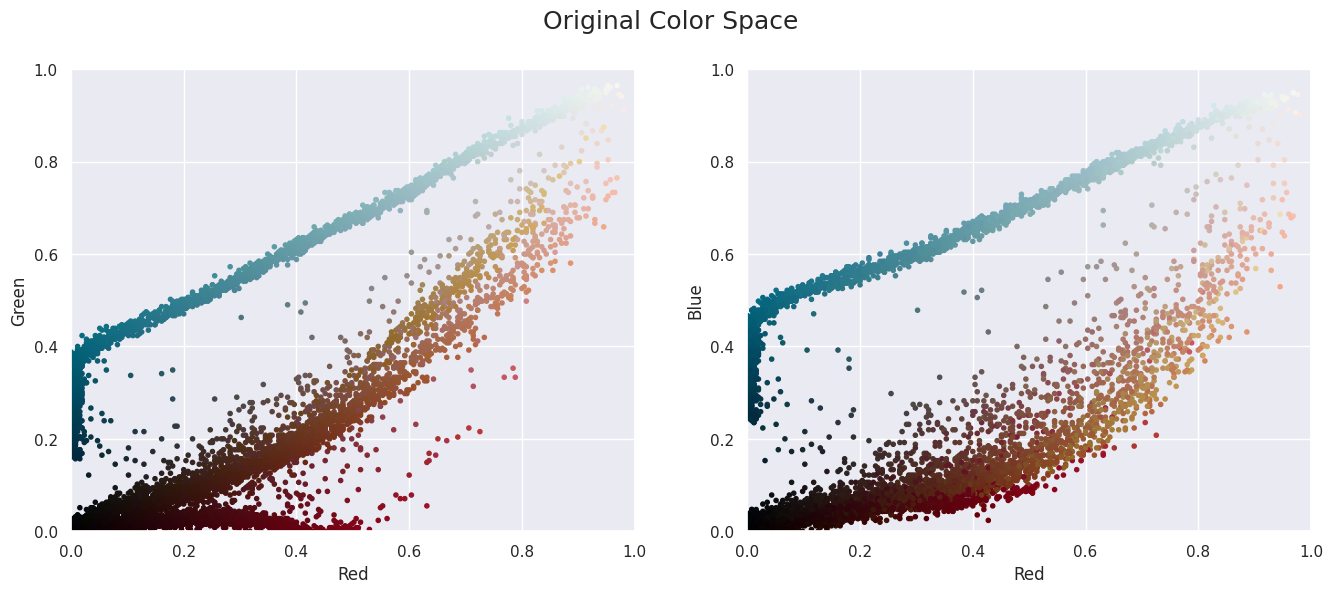

In [15]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    rng = np.random.default_rng(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=18)

plot_pixels(data_img, title='Original Color Space')



## Apply K-Means Clustering


In [16]:
kmeans_img = MiniBatchKMeans(n_clusters=16, random_state=0)
kmeans_img.fit(data_img)

new_colors = kmeans_img.cluster_centers_[kmeans_img.predict(data_img)]



## Reduced Color Space



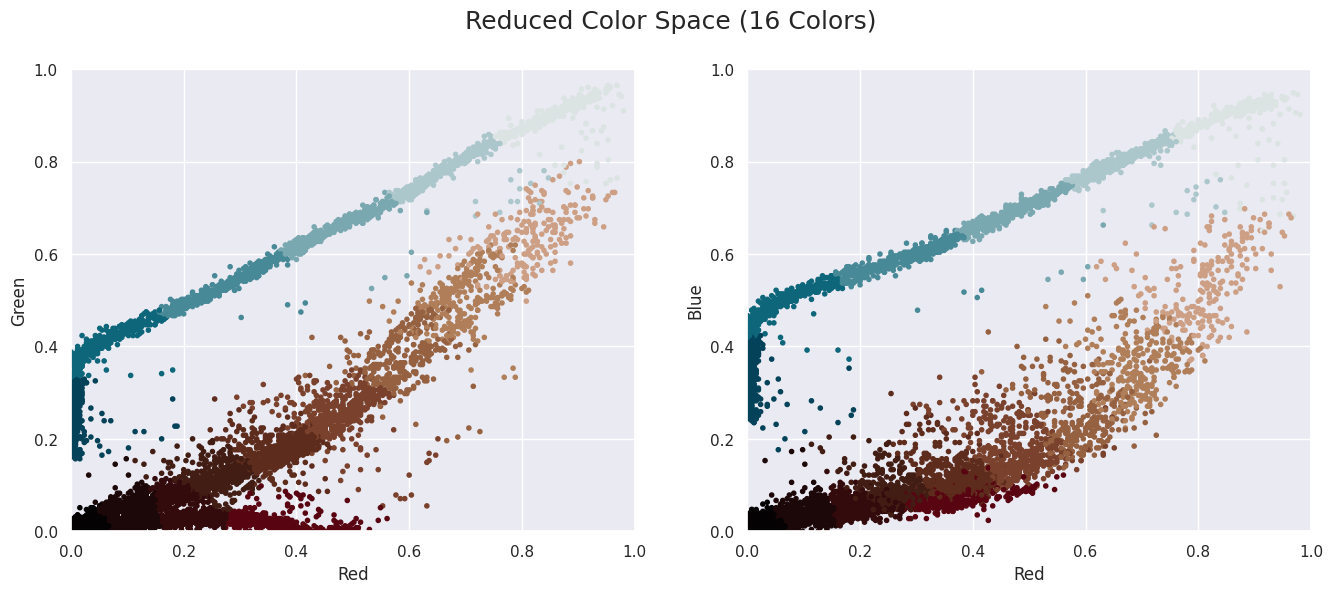

In [17]:
plot_pixels(
    data_img,
    colors=new_colors,
    title='Reduced Color Space (16 Colors)'
)



## Reconstruct Image



In [18]:
download_recolored = new_colors.reshape(download.shape)



## Original vs Recolored Image



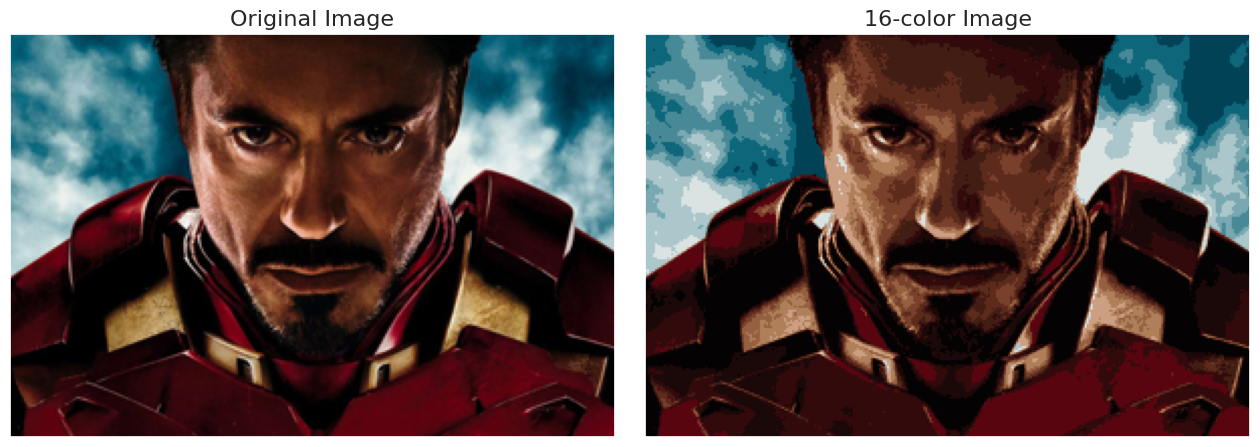

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)

ax[0].imshow(download)
ax[0].set_title('Original Image', size=16)

ax[1].imshow(download_recolored)
ax[1].set_title('16-color Image', size=16)

plt.show()

---

### **PART 38 (MARKDOWN)**

## Conclusion

K-Means clustering groups similar pixel colors and replaces them with cluster centroids. This reduces the image to a fixed number of representative colors while preserving the overall visual structure.

<div class="md-recitation">
  Sources
  <ol>
  <li><a href="https://www.scribd.com/document/730554354/Practicals">https://www.scribd.com/document/730554354/Practicals</a></li>
  <li><a href="https://juejin.cn/post/7381372402985091113">https://juejin.cn/post/7381372402985091113</a></li>
  <li><a href="https://juejin.cn/post/7381372402985091113">https://juejin.cn/post/7381372402985091113</a></li>
  <li><a href="https://juejin.cn/post/7381372402985091113">https://juejin.cn/post/7381372402985091113</a></li>
  </ol>
</div>